<a href="https://colab.research.google.com/github/larissavaladao/py6s_harmonize_sample/blob/main/3.manage_data/data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Notebook overview
This notebook loads Landsat sampling datasets (LD7 and LD8), cleans records with radiometric issues, removes duplicated samples by keeping the temporally closest observation, merges satellite datasets, and evaluates distributions of time differences between image acquisition and field sampling. It produces two merged outputs: one that keeps the temporally closest image per sample, and another that prioritizes LD8 images.

# Import packages

In [26]:
import pandas as pd
import seaborn as sns
import os

In [27]:
# from google.colab import drive
# drive.mount('/content/drive')

# Import satellite data

In [28]:
data_directory = 'C:/Users/l_v_v/Documents/GitHub/time_series_curuai/datasets/Landsat Sampling'

In [29]:
ld7_path = 'py6s_LD7_data.csv'
ld8_path = 'py6s_LD8_data.csv'

***Dataframe columns are described in *'time_series_curuai\datasets\Original Field Sampling\Dataset_CFP.xlsx'* and Roque et al.2014.***

**Columns added:**
- 'CLOUD_COVER' - images cloud cover percentage
- '*band*_max' - maximum pixel value within the windown for the band
- '*band*_mean'- mean pixel value within the windown for the band
- '*band*_median'- median pixel value within the windown for the band
- '*band*_min'- minimum pixel value within the windown for the band
- '*band*_stdDev' - standard deviation for pixel values within the windown for the band
- 'count_pixel' - number of valid, non-masked pixels 
- 'datetime' - image date
- 'dif_date_point'- diference in days from the satellite passage and the field samnpling 
- 'system_index' - image name within the GEE assets

In [30]:
# Remove records with radiometric issues and keep only depth class 1
#Landsat 8
ld8_df = pd.read_csv(os.path.join(data_directory, ld8_path))
ld8_df = ld8_df.loc[(ld8_df['DEPTH_CLASS']==1) & (ld8_df['blue_mean'] > 0) & (ld8_df['green_mean'] > 0) & (ld8_df['red_mean'] > 0) & (ld8_df['nir_mean'] > 0)].copy()
ld8_df['dif_date_point_abs'] = ld8_df['dif_date_point'].apply(lambda x : abs(x))
ld8_df

,CHLOROPHYLL,CHLOROPHYLL_A,CHLOROPHYLL_B,CLOUD_COVER,DEPTH_CLASS,DOC,ID,LATITUDE,LOCATION,LONGITUDE,...,nir_median,nir_min,nir_stdDev,red_max,red_mean,red_median,red_min,red_stdDev,system_index,dif_date_point_abs
0,1.906667,9.326880,0.9149999999999994,22.92,1,3.890,71,-2.258797,PQ,-55.623565,...,0.004178,0.004031,0.000063,0.016487,0.015307,0.015176,0.014848,0.000504,71_1_BOA_LC08_228061_20130916,7.965948
1,1.906667,9.326880,0.9149999999999994,28.02,1,3.890,71,-2.258797,PQ,-55.623565,...,0.004188,0.004009,0.000081,0.015268,0.014886,0.014864,0.014402,0.000271,71_1_BOA_LC08_228062_20130916,7.966225
4,2.216667,44.738425,0.8987750000000037,22.92,1,4.380,73,-2.251349,PQ,-55.543966,...,0.009903,0.008937,0.001145,0.014206,0.012145,0.013450,0.008192,0.002143,73_1_BOA_LC08_228061_20130916,7.111781
5,2.216667,44.738425,0.8987750000000037,28.02,1,4.380,73,-2.251349,PQ,-55.543966,...,0.011236,0.008635,0.001831,0.013655,0.011582,0.011210,0.008004,0.002016,73_1_BOA_LC08_228062_20130916,7.112058
6,1.923333,12.126820,0.8066000000000019,22.92,1,4.119,74,-2.240289,PQ,-55.582417,...,0.004574,0.004198,0.000403,0.014969,0.014365,0.014539,0.013606,0.000463,74_1_BOA_LC08_228061_20130916,7.149976
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,0.873333,6.734240,0.1568800000000005,90.78,1,7.448,351,-2.157200,SL,-55.805249,...,0.018975,0.016928,0.003848,0.020720,0.020114,0.020087,0.019581,0.000429,351_1_BOA_LC08_228062_20170420,6.197080
419,0.665000,9.534840,0.4273000000000017,86.62,1,8.548,353,-2.177378,SL,-55.806321,...,0.015891,0.015700,0.000140,0.026803,0.026105,0.026138,0.025422,0.000487,353_1_BOA_LC08_228061_20170420,6.172498
420,0.665000,9.534840,0.4273000000000017,90.78,1,8.548,353,-2.177378,SL,-55.806321,...,0.015879,0.015565,0.000141,0.026508,0.026091,0.026083,0.025015,0.000471,353_1_BOA_LC08_228062_20170420,6.172775
421,1.693333,47.550140,4.95269999999999,60.80,1,6.693,356,-2.245385,LG,-55.240660,...,0.006562,-0.000259,0.006068,0.031632,0.025192,0.025419,0.018819,0.004006,356_1_BOA_LC08_228061_20170404,13.962813


In [31]:
# Remove records with radiometric issues and keep only depth class 1
#Landsat 7
ld7_df = pd.read_csv(os.path.join(data_directory,ld7_path))
# ld7_df = ld7_df.loc[(ld7_df['DEPTH_CLASS']==1) & (ld7_df['blue_stdDev'] < 0.025) & (ld7_df['green_stdDev'] < 0.025)].copy()
ld7_df = ld7_df.loc[(ld7_df['DEPTH_CLASS']==1) & (ld7_df['blue_mean'] > 0) & (ld7_df['green_mean'] > 0) & (ld7_df['red_mean'] > 0) & (ld7_df['nir_mean'] > 0)].copy()
ld7_df['dif_date_point_abs'] = ld7_df['dif_date_point'].apply(lambda x : abs(x))
ld7_df

,CHLOROPHYLL,CHLOROPHYLL_A,CHLOROPHYLL_B,CLOUD_COVER,DEPTH_CLASS,DOC,ID,LATITUDE,LOCATION,LONGITUDE,...,nir_median,nir_min,nir_stdDev,red_max,red_mean,red_median,red_min,red_stdDev,system_index,dif_date_point_abs
2,0.699333,2.1440399999999995,1.9471400000000005,51,1,2.854,3,-2.196960,LG,-55.299530,...,0.017404,0.015301,0.001615,0.036406,0.033052,0.033643,0.019369,0.005217,3_1_BOA_LE07_228061_20130316,7.104249
3,0.699333,2.1440399999999995,1.9471400000000005,73,1,2.854,3,-2.196960,LG,-55.299530,...,0.017394,0.014111,0.003252,0.036275,0.033894,0.036167,0.019373,0.005545,3_1_BOA_LE07_228062_20130316,7.104526
4,0.827333,10.23478,8.205020000000001,51,1,1.017,4,-2.221738,LG,-55.270194,...,0.012970,0.011843,0.000452,0.034967,0.034728,0.034775,0.034042,0.000275,4_1_BOA_LE07_228061_20130316,7.034804
5,0.827333,10.23478,8.205020000000001,73,1,1.017,4,-2.221738,LG,-55.270194,...,0.013088,0.012305,0.000451,0.035511,0.034867,0.034885,0.034058,0.000451,4_1_BOA_LE07_228062_20130316,7.035081
12,1.210000,44.09388,19.88334,51,1,1.390,8,-2.209570,LG,-55.347110,...,0.009354,0.009025,0.000521,0.024393,0.021370,0.021460,0.020350,0.001295,8_1_BOA_LE07_228061_20130316,6.968832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
547,1.855714,9.97784,NaN,0,1,7.666,331,-2.176470,SL,-55.813190,...,0.049422,0.046517,0.001238,0.047724,0.046797,0.046794,0.045720,0.000602,331_1_BOA_LE07_228061_20161018,12.039398
548,1.855714,9.97784,NaN,30,1,7.666,331,-2.176470,SL,-55.813190,...,0.025212,0.024359,0.000531,0.043166,0.042611,0.042529,0.041976,0.000344,331_1_BOA_LE07_228062_20161002,3.960310
549,1.855714,9.97784,NaN,34,1,7.666,331,-2.176470,SL,-55.813190,...,0.049193,0.046132,0.001487,0.047880,0.046713,0.046865,0.045322,0.000794,331_1_BOA_LE07_228062_20161018,12.039675
551,NaN,12.21164,NaN,16,1,7.494,332,-2.186020,AM,-54.966290,...,0.009511,0.008341,0.000782,0.022862,0.021328,0.021238,0.020483,0.000660,332_1_BOA_LE07_227062_20161011,5.202063


Remove duplicated records, keeping the one temporally closest to the sampling date

In [32]:
ID_ld7 = ld7_df['ID'].unique()
ID_ld8 = ld8_df['ID'].unique()
print('LD7 Uinque IDS',ID_ld7)
print('LD8 Uinque IDS',ID_ld8)

LD7 Uinque IDS [  3   4   8  16  20  21  27  29  30  34  40  43  44  54  60  63  64  68
  69  70  71  73  74  79  80  81  82  83  86  88  89  92  93  97  98  99
 102 103 104 105 106 107 112 114 115 116 120 121 122 123 124 127 130 132
 136 140 143 144 147 148 151 152 155 156 157 158 159 160 165 166 167 168
 171 172 173 174 175 176 177 178 179 180 186 187 188 190 192 193 194 195
 203 206 212 213 218 219 220 221 222 223 224 225 227 228 229 231 233 234
 235 236 237 238 239 240 241 242 243 245 246 247 248 250 251 253 256 257
 258 259 260 266 270 273 279 280 281 282 283 284 285 286 287 290 291 292
 293 295 296 297 298 299 301 302 303 304 305 306 307 310 311 312 313 315
 316 317 318 319 320 321 322 324 325 326 327 328 329 330 331 332 346]
LD8 Uinque IDS [ 71  73  74  75  76  79  80  83  86  87  97  98  99 102 104 105 107 114
 115 116 120 121 122 123 124 127 130 131 132 133 136 140 143 144 147 149
 151 152 155 156 158 160 171 172 173 174 175 176 177 178 179 180 186 187
 190 191 192 193 194 195

In [33]:
DATE_ld7 = ld7_df['datetime'].unique()
DATE_ld8 = ld8_df['datetime'].unique()

print('LD7 Uinque DATE',DATE_ld7)
print('LD8 Uinque DATE',DATE_ld8)

LD7 Uinque DATE ['2013-03-09 11:20:00' '2013-03-09 13:00:00' '2013-03-09 14:35:00'
 '2013-03-11 08:00:00' '2013-03-11 11:20:00' '2013-03-11 13:00:00'
 '2013-03-11 16:30:00' '2013-03-12 08:30:00' '2013-03-12 10:15:00'
 '2013-03-12 11:15:00' '2013-03-12 15:30:00' '2013-03-13 11:30:00'
 '2013-03-13 12:00:00' '2013-03-15 13:30:00' '2013-03-16 13:00:00'
 '2013-03-17 10:30:00' '2013-03-17 11:14:00' '2013-03-17 13:15:00'
 '2013-03-18 09:15:00' '2013-03-18 09:00:00' '2013-09-08 14:45:00'
 '2013-09-09 11:15:00' '2013-09-09 10:20:00' '2013-09-10 09:00:00'
 '2013-09-10 11:45:00' '2013-09-10 14:00:00' '2013-09-10 14:40:00'
 '2013-09-10 17:15:00' '2013-09-11 18:00:00' '2013-09-11 10:00:00'
 '2013-09-11 08:30:00' '2013-09-11 11:10:00' '2013-09-11 13:30:00'
 '2013-09-12 09:00:00' '2013-09-12 17:30:00' '2013-09-12 13:30:00'
 '2013-09-12 14:30:00' '2013-09-12 15:45:00' '2013-09-12 12:00:00'
 '2013-09-13 14:00:00' '2013-09-13 15:00:00' '2013-09-13 16:30:00'
 '2013-09-14 13:40:00' '2013-09-14 15:00:00' '

In [34]:
SAMPLE_SITE_ld7 = ld7_df['SAMPLE_SITE'].sort_values().unique()
SAMPLE_SITE_ld8 = ld8_df['SAMPLE_SITE'].sort_values().unique()

print('LD7 Uinque SAMPLE_SITE',SAMPLE_SITE_ld7)
print('LD8 Uinque SAMPLE_SITE',SAMPLE_SITE_ld8)

LD7 Uinque SAMPLE_SITE [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 36 37 38 39 40 41 42 43 44 45 46 47 48]
LD8 Uinque SAMPLE_SITE [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 36 37 38 39 40 41 42 43 44 45 46 47 48 49]


In [35]:
x = ld7_df.groupby(['datetime','SAMPLE_SITE'])['system_index'].count()
z = x.loc[(x<2)]
print('no duplicated image samples for the same database sample LD7: ',z.count())
y = x.loc[(x>2)]

print('multiple image samples for the same database sample LD7: ',y.count())
v = x.loc[(x==2)]

print('duplicated image samples for the same database sample LD7: ',v.count())


no duplicated image samples for the same database sample LD7:  44
multiple image samples for the same database sample LD7:  26
duplicated image samples for the same database sample LD7:  109


In [36]:
x = ld8_df.groupby(['datetime','SAMPLE_SITE'])['system_index'].count()
z = x.loc[(x<2)]
print('no duplicated image samples for the same database sample LD8: ',z.count())
y = x.loc[(x>2)]

print('multiple image samples for the same database sample LD8: ',y.count())
v = x.loc[(x==2)]

print('duplicated image samples for the same database sample LD8: ',v.count())

no duplicated image samples for the same database sample LD8:  21
multiple image samples for the same database sample LD8:  30
duplicated image samples for the same database sample LD8:  71


In [37]:
list_duplicatesld7 = []
list_multipleld7 = []
list_ld7 = []
for i in DATE_ld7:
  for j in SAMPLE_SITE_ld7:
    gdf = ld7_df.loc[(ld7_df['datetime'] == i) & (ld7_df['SAMPLE_SITE'] == j)].copy()
    gdf = gdf.loc[gdf['dif_date_point_abs'] == gdf['dif_date_point_abs'].min()].copy()
    if len(gdf) == 2:
      list_duplicatesld7.append(gdf)
    elif len(gdf) > 2:
      list_multipleld7.append(gdf)
    elif len(gdf) ==1:
      list_ld7.append(gdf)
print(len(list_duplicatesld7))
print(len(list_multipleld7))
print(len(list_ld7))

0
0
179


In [38]:
list_duplicatesld8 = []
list_multipleld8 = []
list_ld8 = []
for i in DATE_ld8:
  for j in SAMPLE_SITE_ld8:
    gdf = ld8_df.loc[(ld8_df['datetime'] == i) & (ld8_df['SAMPLE_SITE'] == j)].copy()
    gdf = gdf.loc[gdf['dif_date_point_abs'] == gdf['dif_date_point_abs'].min()].copy()
    if len(gdf) == 2:
      list_duplicatesld8.append(gdf)
    elif len(gdf) > 2:
      list_multipleld8.append(gdf)
    elif len(gdf) ==1:
      list_ld8.append(gdf)
print(len(list_duplicatesld8))
print(len(list_multipleld8))
print(len(list_ld8))

0
0
122


In [39]:
clean_ld7 = pd.concat(list_ld7).sort_values(by=['LOCATION'], ascending=False)
clean_ld8 = pd.concat(list_ld8).sort_values(by=['LOCATION'], ascending=False)
clean_ld7

,CHLOROPHYLL,CHLOROPHYLL_A,CHLOROPHYLL_B,CLOUD_COVER,DEPTH_CLASS,DOC,ID,LATITUDE,LOCATION,LONGITUDE,...,nir_median,nir_min,nir_stdDev,red_max,red_mean,red_median,red_min,red_stdDev,system_index,dif_date_point_abs
472,1.418333e+00,55.77477666666667,8.650813333333334,43,1,5.116,299,-2.037612,SN,-55.486403,...,0.017091,0.016585,0.000450,0.047536,0.046011,0.046233,0.040168,0.002165,299_1_BOA_LE07_228061_20160409,10.022075
216,1.495000e+00,1.5666400000000003,0.35846,23,1,4.459,160,-2.095675,SN,-55.488855,...,0.004308,0.001467,0.001050,0.016304,0.015220,0.015210,0.013384,0.000780,160_1_BOA_LE07_228061_20140607,9.035698
520,2.298810e+00,11.806579999999997,NaN,9,1,8.031,322,-2.046090,SN,-55.484860,...,0.033960,0.033624,0.000565,0.045001,0.044237,0.044322,0.043911,0.000333,322_1_BOA_LE07_228061_20161002,1.866837
523,2.676842e+00,12.353980000000002,NaN,9,1,7.260,324,-2.061520,SN,-55.461190,...,0.032569,0.032000,0.000704,0.048466,0.047920,0.048032,0.046398,0.000582,324_1_BOA_LE07_228061_20161002,1.849707
471,NaN,55.01353444444444,1.468000000000002,43,1,5.197,298,-2.070564,SN,-55.486853,...,0.004158,0.002776,0.000997,0.021038,0.015644,0.014214,0.011768,0.002609,298_1_BOA_LE07_228061_20160409,9.955409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
436,NaN,NaN,NaN,62,1,NaN,279,-2.180361,AM,-55.016444,...,0.010978,0.010179,0.000417,0.031128,0.029488,0.029788,0.025855,0.001654,279_1_BOA_LE07_228061_20150525,13.578789
189,1.140000e+00,8.426428571428573,0.07022857142857118,52,1,3.414,143,-2.180361,AM,-55.016444,...,0.006143,0.005757,0.000463,0.024673,0.024085,0.024054,0.023567,0.000320,143_1_BOA_LE07_227062_20131003,14.947267
404,5.336364e-07,1.6806999999999994,0.3010000000000005,1,1,2.311,253,-2.180361,AM,-55.016444,...,0.011923,0.010884,0.000598,0.035758,0.035292,0.035258,0.034671,0.000296,253_1_BOA_LE07_228061_20141130,2.852528
551,NaN,12.21164,NaN,16,1,7.494,332,-2.186020,AM,-54.966290,...,0.009511,0.008341,0.000782,0.022862,0.021328,0.021238,0.020483,0.000660,332_1_BOA_LE07_227062_20161011,5.202063


In [40]:
clean_ld7.columns

Index(['CHLOROPHYLL', 'CHLOROPHYLL_A', 'CHLOROPHYLL_B', 'CLOUD_COVER',
       'DEPTH_CLASS', 'DOC', 'ID', 'LATITUDE', 'LOCATION', 'LONGITUDE',
       'MISSION', 'N_TOTAL', 'N_TOTAL_DISSOLVED', 'POC', 'P_ORGANIC',
       'P_TOTAL', 'SAMPLE_SITE', 'SAMPLING_DEPTH', 'SILICA', 'SPM', 'TOC',
       'TOTAL_DEPTH', 'TURBIDITY', 'WATER_PERIOD', 'blue_max', 'blue_mean',
       'blue_median', 'blue_min', 'blue_stdDev', 'count_pixel', 'datetime',
       'dif_date_point', 'green_max', 'green_mean', 'green_median',
       'green_min', 'green_stdDev', 'img_date', 'nir_max', 'nir_mean',
       'nir_median', 'nir_min', 'nir_stdDev', 'red_max', 'red_mean',
       'red_median', 'red_min', 'red_stdDev', 'system_index',
       'dif_date_point_abs'],
      dtype='object')

# Data distribution per satellite

## number of points by difference between image date and sampling date

### Color by location

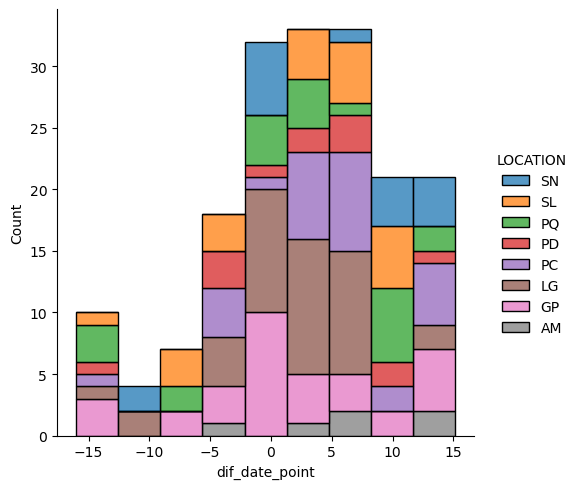

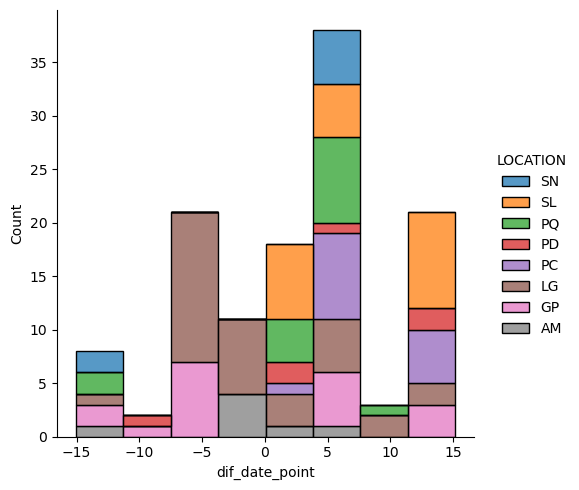

In [41]:
sns.displot(data=clean_ld7, x="dif_date_point",hue='LOCATION', multiple="stack")
sns.displot(data=clean_ld8, x="dif_date_point",hue='LOCATION', multiple="stack")

#### Color by location without AM (amazon river field points)

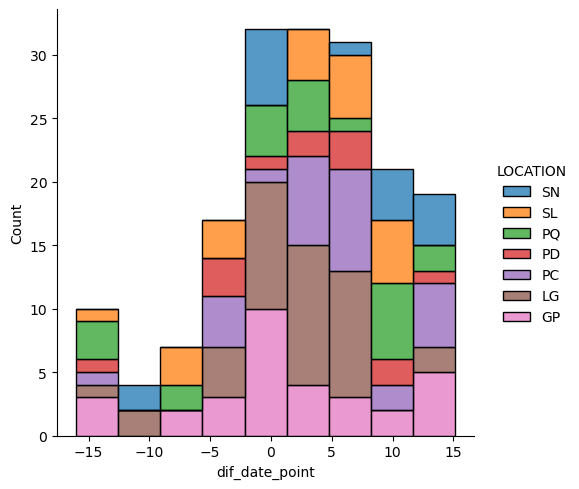

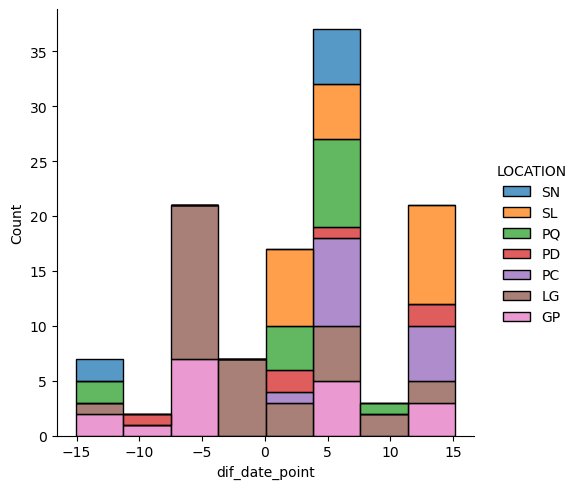

In [42]:
sns.displot(data=clean_ld7.loc[clean_ld7['LOCATION']!='AM'], x="dif_date_point",hue='LOCATION', multiple="stack")
sns.displot(data=clean_ld8.loc[clean_ld8['LOCATION']!='AM'], x="dif_date_point",hue='LOCATION', multiple="stack")

### Color by water period

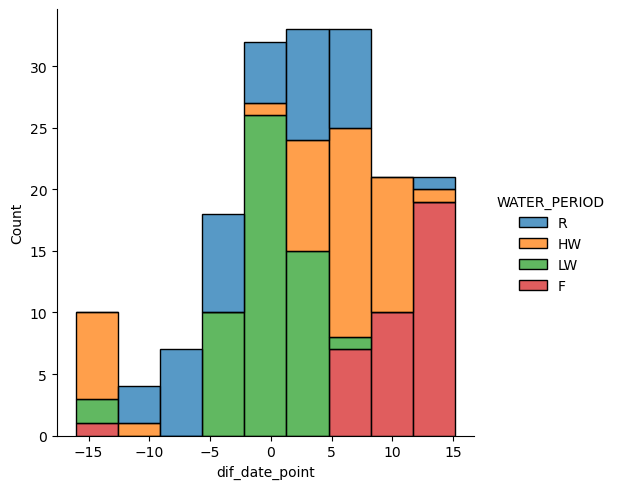

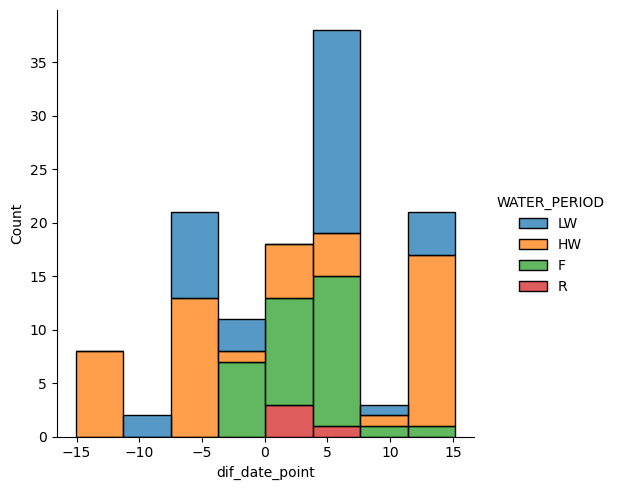

In [43]:
sns.displot(data=clean_ld7, x="dif_date_point",hue='WATER_PERIOD', multiple="stack")
sns.displot(data=clean_ld8, x="dif_date_point",hue='WATER_PERIOD', multiple="stack")

#### Color by water period without AM

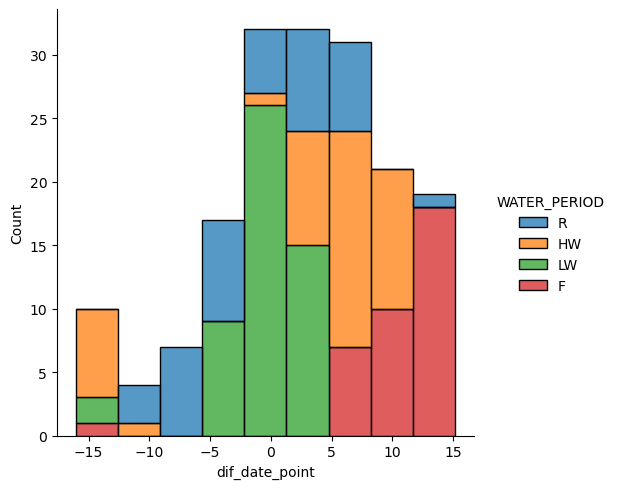

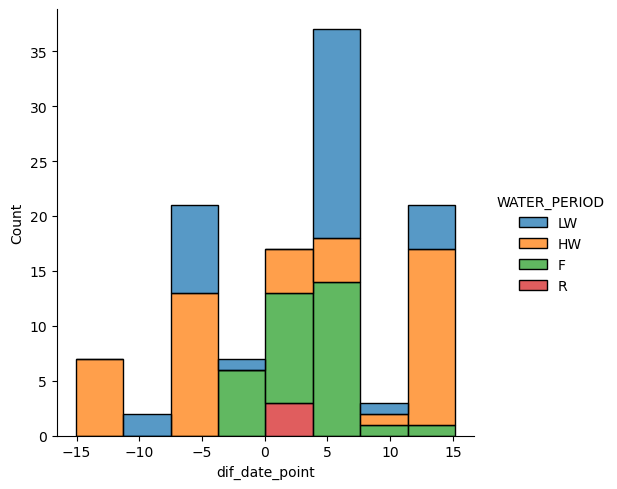

In [44]:
sns.displot(data=clean_ld7.loc[clean_ld7['LOCATION']!='AM'], x="dif_date_point",hue='WATER_PERIOD', multiple="stack")
sns.displot(data=clean_ld8.loc[clean_ld8['LOCATION']!='AM'], x="dif_date_point",hue='WATER_PERIOD', multiple="stack")

## number of points by field sampling mission

### Color by location

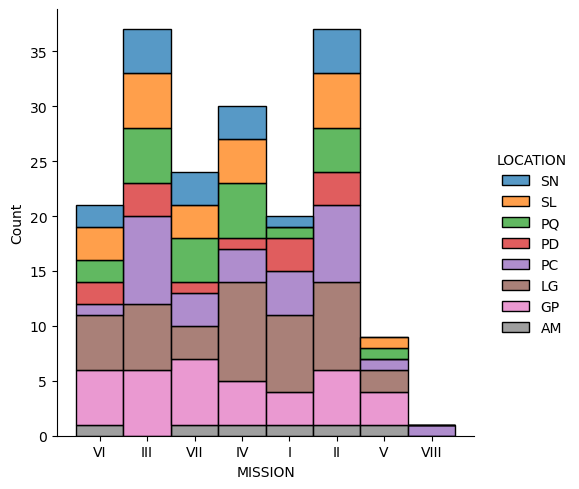

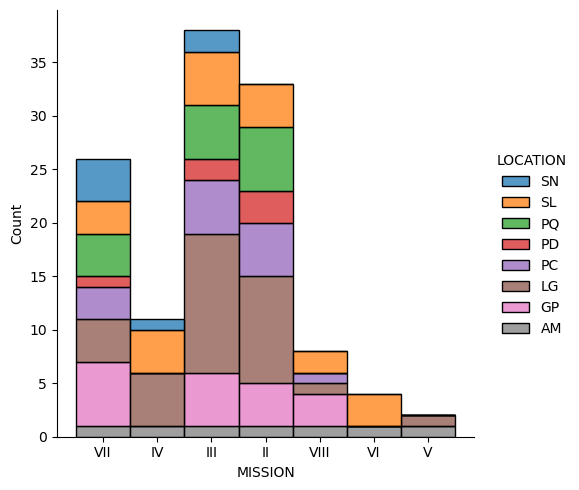

In [45]:
sns.displot(data=clean_ld7, x="MISSION",hue='LOCATION', multiple="stack")
sns.displot(data=clean_ld8, x="MISSION",hue='LOCATION', multiple="stack")

#### Color by location without AM

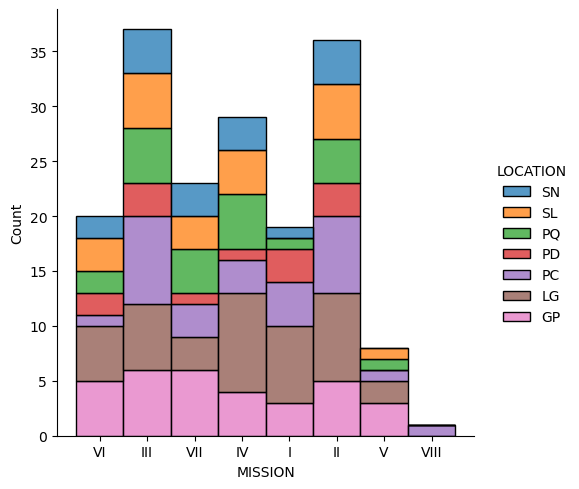

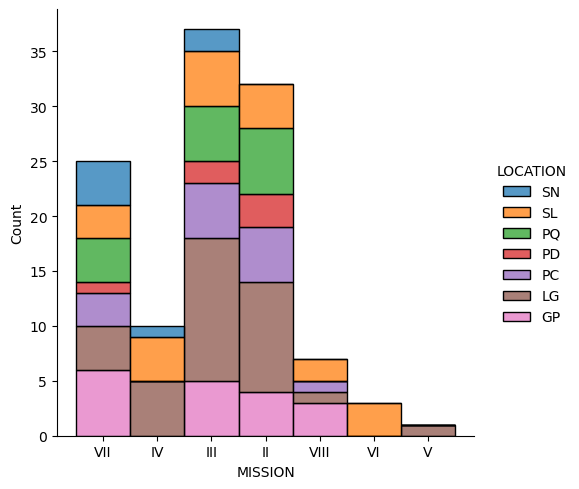

In [46]:
sns.displot(data=clean_ld7.loc[clean_ld7['LOCATION']!='AM'], x="MISSION",hue='LOCATION', multiple="stack")
sns.displot(data=clean_ld8.loc[clean_ld8['LOCATION']!='AM'], x="MISSION",hue='LOCATION', multiple="stack")

# Merge data from both satellites

In [47]:
clean_ld7['satellite']='LD7'
clean_ld8['satellite']='LD8'

merge_LD = pd.concat([clean_ld7,clean_ld8]).sort_values(by=['ID'])
merge_LD.head(75)

,CHLOROPHYLL,CHLOROPHYLL_A,CHLOROPHYLL_B,CLOUD_COVER,DEPTH_CLASS,DOC,ID,LATITUDE,LOCATION,LONGITUDE,...,nir_min,nir_stdDev,red_max,red_mean,red_median,red_min,red_stdDev,system_index,dif_date_point_abs,satellite
2,0.699333,2.1440399999999995,1.9471400000000005,51.00,1,2.854,3,-2.196960,LG,-55.299530,...,0.015301,0.001615,0.036406,0.033052,0.033643,0.019369,0.005217,3_1_BOA_LE07_228061_20130316,7.104249,LD7
4,0.827333,10.23478,8.205020000000001,51.00,1,1.017,4,-2.221738,LG,-55.270194,...,0.011843,0.000452,0.034967,0.034728,0.034775,0.034042,0.000275,4_1_BOA_LE07_228061_20130316,7.034804,LD7
12,1.210000,44.09388,19.88334,51.00,1,1.390,8,-2.209570,LG,-55.347110,...,0.009025,0.000521,0.024393,0.021370,0.021460,0.020350,0.001295,8_1_BOA_LE07_228061_20130316,6.968832,LD7
14,0.478824,5.2461400000000005,4.278520000000001,51.00,1,3.665,16,-2.262023,PQ,-55.456187,...,0.019084,0.000643,0.044551,0.043502,0.043352,0.042320,0.000732,16_1_BOA_LE07_228061_20130316,5.243138,LD7
22,0.763571,4.81448,"< 0,01",73.00,1,3.381,20,-2.175347,GP,-55.490867,...,0.012361,0.000535,0.029138,0.027611,0.027587,0.026740,0.000896,20_1_BOA_LE07_228062_20130316,5.104526,LD7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,1.290000,85.8194,"< 0,01",22.92,1,2.982,122,-2.178437,PD,-55.633239,...,0.006199,0.000083,0.026285,0.025867,0.026016,0.024663,0.000528,122_1_BOA_LC08_228061_20130916,1.153448,LD8
151,1.290000,85.8194,"< 0,01",1.00,1,2.982,122,-2.178437,PD,-55.633239,...,0.008601,0.000445,0.023521,0.021882,0.022392,0.020201,0.001009,122_1_BOA_LE07_228061_20130924,9.149110,LD7
66,2.376585,44.1313,"< 0,01",22.92,1,4.684,123,-2.238955,LG,-55.339160,...,0.005820,0.000146,0.024559,0.024249,0.024242,0.024007,0.000171,123_1_BOA_LC08_228061_20130916,0.143031,LD8
153,2.376585,44.131299999999996,"< 0,01",1.00,1,4.684,123,-2.238955,LG,-55.339160,...,0.008746,0.000485,0.024464,0.023644,0.023611,0.022373,0.000566,123_1_BOA_LE07_228061_20130924,8.138693,LD7


## Remove duplicated data between satellites

Two datasets generated: one prioritizes the temporally closest observation, and the other prioritizes LD8 observations.

In [48]:
x = merge_LD.groupby(['ID','SAMPLE_SITE'])['system_index'].count()
z = x.loc[(x<2)]
print('no duplicated image samples for the same database sample: ',z.count())
y = x.loc[(x>2)]

print('multiple image samples for the same database sample: ',y.count())
v = x.loc[(x==2)]

print('duplicated image samples for the same database sample: ',v.count())

no duplicated image samples for the same database sample:  107
multiple image samples for the same database sample:  0
duplicated image samples for the same database sample:  97


In [49]:
merge_LD['duplicated'] = merge_LD.duplicated(subset=['ID'])

ID_merge = merge_LD.loc[merge_LD['duplicated'] == True]
ID_merge = ID_merge['ID'].unique()
ID_merge

array([ 71,  73,  74,  79,  80,  83,  86,  97,  98,  99, 102, 104, 105,
       107, 114, 115, 116, 120, 121, 122, 123, 124, 127, 130, 132, 136,
       140, 143, 144, 147, 151, 152, 155, 156, 158, 160, 171, 172, 173,
       174, 175, 176, 177, 178, 179, 180, 186, 187, 190, 192, 193, 194,
       195, 203, 206, 212, 213, 218, 219, 220, 221, 233, 241, 248, 250,
       251, 253, 279, 290, 291, 292, 304, 305, 306, 307, 310, 311, 312,
       313, 315, 316, 317, 318, 319, 320, 321, 322, 324, 325, 326, 327,
       328, 329, 330, 331, 332, 346])

In [50]:
merge_LD

,CHLOROPHYLL,CHLOROPHYLL_A,CHLOROPHYLL_B,CLOUD_COVER,DEPTH_CLASS,DOC,ID,LATITUDE,LOCATION,LONGITUDE,...,nir_stdDev,red_max,red_mean,red_median,red_min,red_stdDev,system_index,dif_date_point_abs,satellite,duplicated
2,0.699333,2.1440399999999995,1.9471400000000005,51.00,1,2.854,3,-2.196960,LG,-55.299530,...,0.001615,0.036406,0.033052,0.033643,0.019369,0.005217,3_1_BOA_LE07_228061_20130316,7.104249,LD7,False
4,0.827333,10.23478,8.205020000000001,51.00,1,1.017,4,-2.221738,LG,-55.270194,...,0.000452,0.034967,0.034728,0.034775,0.034042,0.000275,4_1_BOA_LE07_228061_20130316,7.034804,LD7,False
12,1.210000,44.09388,19.88334,51.00,1,1.390,8,-2.209570,LG,-55.347110,...,0.000521,0.024393,0.021370,0.021460,0.020350,0.001295,8_1_BOA_LE07_228061_20130316,6.968832,LD7,False
14,0.478824,5.2461400000000005,4.278520000000001,51.00,1,3.665,16,-2.262023,PQ,-55.456187,...,0.000643,0.044551,0.043502,0.043352,0.042320,0.000732,16_1_BOA_LE07_228061_20130316,5.243138,LD7,False
22,0.763571,4.81448,"< 0,01",73.00,1,3.381,20,-2.175347,GP,-55.490867,...,0.000535,0.029138,0.027611,0.027587,0.026740,0.000896,20_1_BOA_LE07_228062_20130316,5.104526,LD7,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
553,1.886000,15.09028,1.4778,82.00,1,8.777,346,-2.142593,PC,-55.625756,...,0.000805,0.023917,0.022239,0.022105,0.021152,0.000844,346_1_BOA_LE07_228061_20170412,1.117138,LD7,False
417,1.886000,15.09028,1.4778,90.78,1,8.777,346,-2.142593,PC,-55.625756,...,0.001034,0.022079,0.021088,0.021067,0.019679,0.000708,346_1_BOA_LC08_228062_20170420,6.881108,LD8,True
418,0.873333,6.73424,0.1568800000000005,90.78,1,7.448,351,-2.157200,SL,-55.805249,...,0.003848,0.020720,0.020114,0.020087,0.019581,0.000429,351_1_BOA_LC08_228062_20170420,6.197080,LD8,False
419,0.665000,9.53484,0.4273000000000017,86.62,1,8.548,353,-2.177378,SL,-55.806321,...,0.000140,0.026803,0.026105,0.026138,0.025422,0.000487,353_1_BOA_LC08_228061_20170420,6.172498,LD8,False


In [51]:
list_merge_min = []
list_merge_LD8 = []
unique_ID = merge_LD['ID'].unique()

for j in unique_ID:
  subset = merge_LD.loc[(merge_LD['ID'] == j)].copy()

  value = subset['ID'].iloc[0].copy()

  if value in ID_merge:
    gdf1 = subset.loc[subset['dif_date_point_abs'] == subset['dif_date_point_abs'].min()].copy()

    gdf2 = subset.loc[subset['satellite'] == 'LD8'].copy()

    print('DUPLICATE')
    print('min ',gdf1['system_index'].iloc[0])
    print('ld8 ',gdf2['system_index'].iloc[0])

    list_merge_min.append(gdf1)
    list_merge_LD8.append(gdf2)

  else:
    list_merge_min.append(subset)
    list_merge_LD8.append(subset)
    # print('NOT DUPLICATE')
    # print('subset',subset['system_index'].iloc[0])




print(len(list_merge_min))

print(len(list_merge_LD8))

DUPLICATE
min  71_1_BOA_LC08_228061_20130916
ld8  71_1_BOA_LC08_228061_20130916
DUPLICATE
min  73_1_BOA_LC08_228061_20130916
ld8  73_1_BOA_LC08_228061_20130916
DUPLICATE
min  74_1_BOA_LC08_228061_20130916
ld8  74_1_BOA_LC08_228061_20130916
DUPLICATE
min  79_1_BOA_LC08_228061_20130916
ld8  79_1_BOA_LC08_228061_20130916
DUPLICATE
min  80_1_BOA_LC08_228061_20130916
ld8  80_1_BOA_LC08_228061_20130916
DUPLICATE
min  83_1_BOA_LC08_228061_20130916
ld8  83_1_BOA_LC08_228061_20130916
DUPLICATE
min  86_1_BOA_LC08_228061_20130916
ld8  86_1_BOA_LC08_228061_20130916
DUPLICATE
min  97_1_BOA_LC08_228061_20130916
ld8  97_1_BOA_LC08_228061_20130916
DUPLICATE
min  98_1_BOA_LC08_228061_20130916
ld8  98_1_BOA_LC08_228061_20130916
DUPLICATE
min  99_1_BOA_LC08_228061_20130916
ld8  99_1_BOA_LC08_228061_20130916
DUPLICATE
min  102_1_BOA_LC08_228061_20130916
ld8  102_1_BOA_LC08_228061_20130916
DUPLICATE
min  104_1_BOA_LC08_228061_20130916
ld8  104_1_BOA_LC08_228061_20130916
DUPLICATE
min  105_1_BOA_LC08_228061

In [52]:
merge_LD_minDate = pd.concat(list_merge_min)
merge_LD_LD8 = pd.concat(list_merge_LD8)

## Evaluate distributions

minimum date difference

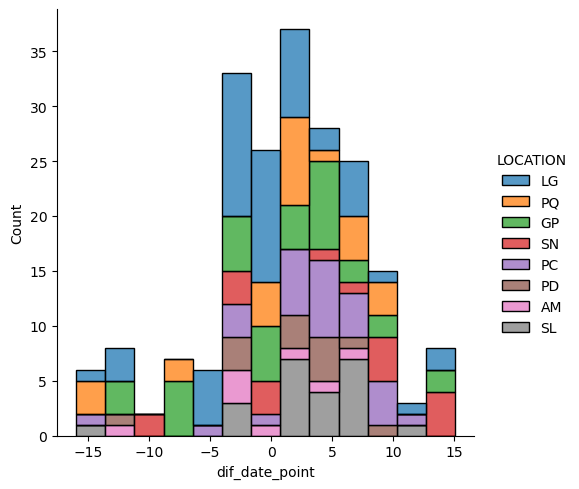

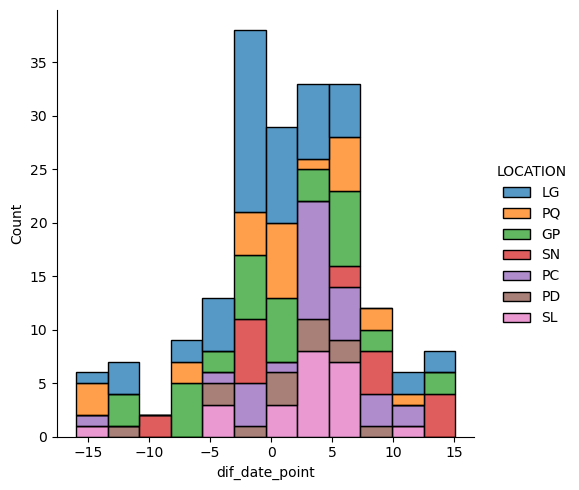

In [53]:
# number of samples by difference between image date and field date
#color by location 
sns.displot(data=merge_LD_minDate, x="dif_date_point",hue='LOCATION', multiple="stack")
# color by location excluding AM
sns.displot(data=merge_LD_minDate.loc[merge_LD_minDate['LOCATION'] != 'AM'], x="dif_date_point",hue='LOCATION', multiple="stack")

Landsat 8 image preference

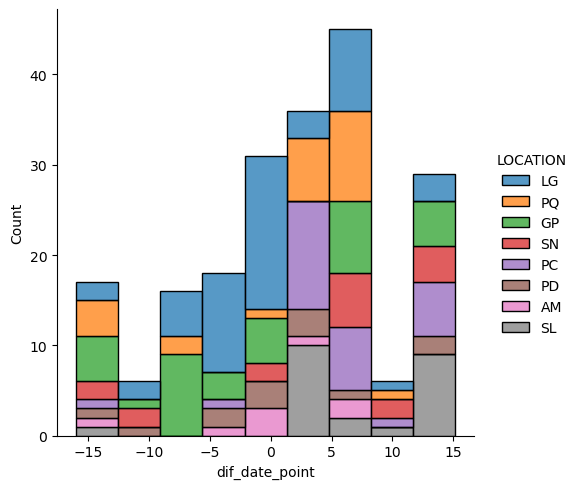

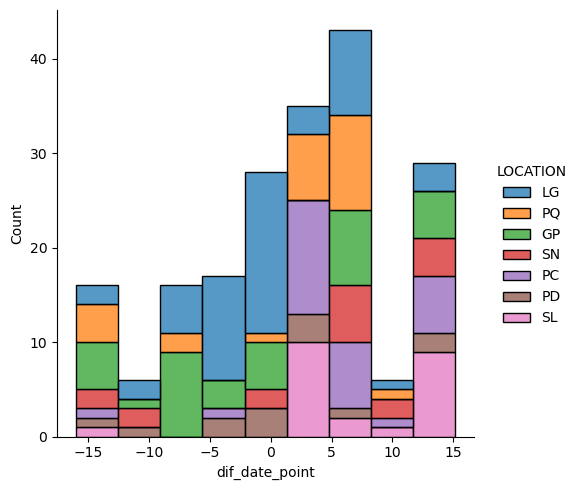

In [54]:
# number of samples by difference between image date and field date
#color by location 
sns.displot(data=merge_LD_LD8, x="dif_date_point",hue='LOCATION', multiple="stack")
# color by location excluding AM
sns.displot(data=merge_LD_LD8.loc[merge_LD_LD8['LOCATION'] != 'AM'], x="dif_date_point",hue='LOCATION', multiple="stack")

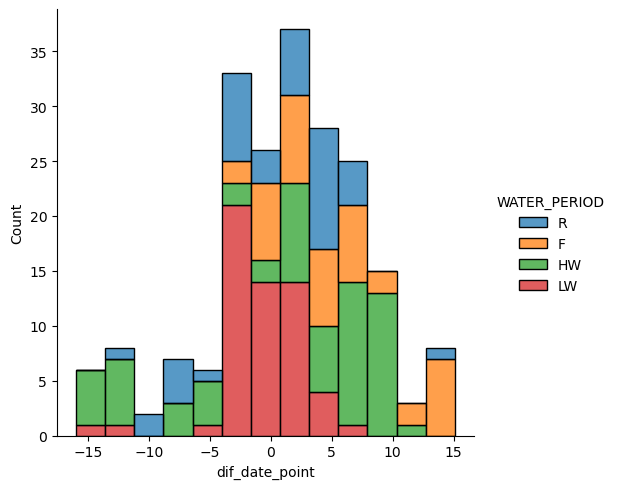

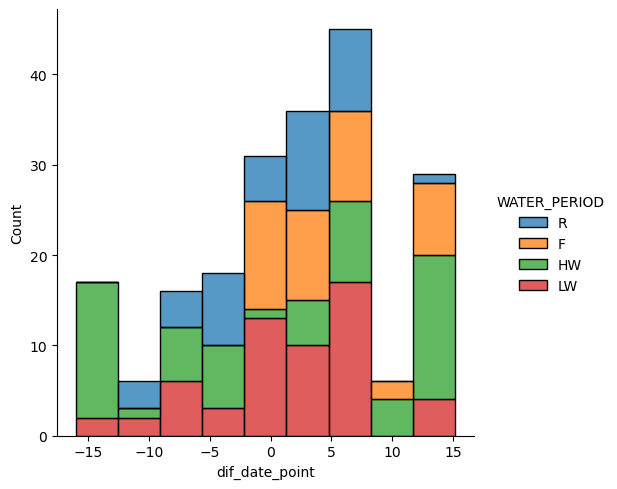

In [55]:
# number of samples by difference between image date and field date
#color by water period
# minimum diference date 
sns.displot(data=merge_LD_minDate, x="dif_date_point",hue='WATER_PERIOD', multiple="stack")
# Landsat 8 preference
sns.displot(data=merge_LD_LD8, x="dif_date_point",hue='WATER_PERIOD', multiple="stack")

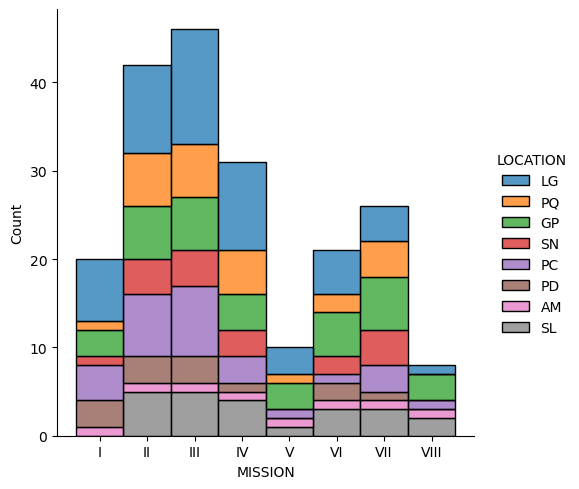

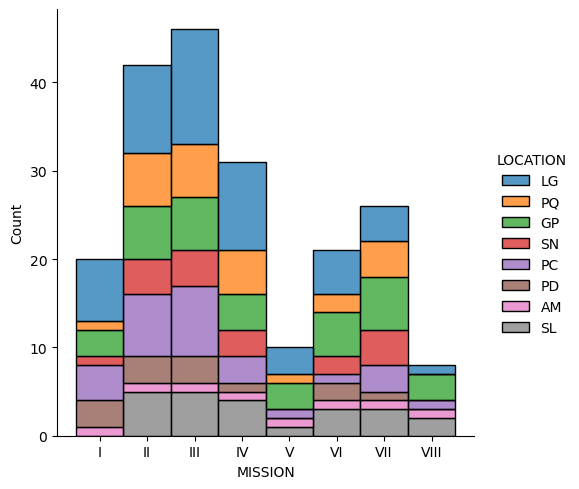

In [56]:
# number of samples by difference between field sampling mission
#color by location
# minimum diference date 
sns.displot(data=merge_LD_minDate, x="MISSION",hue='LOCATION', multiple="stack")
# Landsat 8 preference
sns.displot(data=merge_LD_LD8, x="MISSION",hue='LOCATION', multiple="stack")

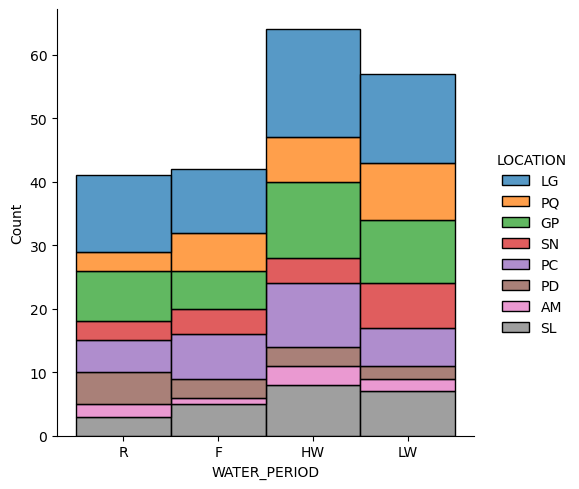

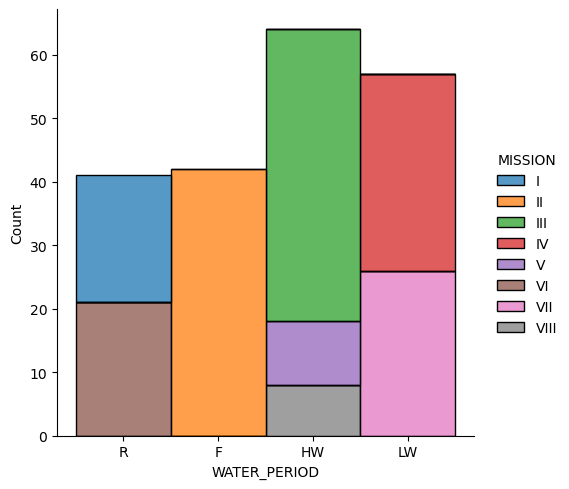

In [57]:
# number of samples by water peiod
#color by location
# minimum diference date 
sns.displot(data=merge_LD_minDate, x="WATER_PERIOD",hue='LOCATION', multiple="stack")
# Landsat 8 preference
sns.displot(data=merge_LD_LD8, x="WATER_PERIOD",hue='MISSION', multiple="stack")

# Export Data

In [59]:
merge_LD_minDate.to_csv(os.path.join(data_directory, 'Merged Landsat Data/min_date.csv'))
merge_LD_LD8.to_csv(os.path.join(data_directory, 'Merged Landsat Data/LD8_priority.csv'))